<a href="https://colab.research.google.com/github/etebongibekwe-stack/Beam-shaping/blob/main/NN_project_%20handwriting_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
## Building neural network medol using tensor flow and keras

In [27]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [28]:
## load dataset

In [29]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [30]:
## check the shape of the data

In [31]:
x_train.shape

(60000, 28, 28)

In [32]:
## visualize some data

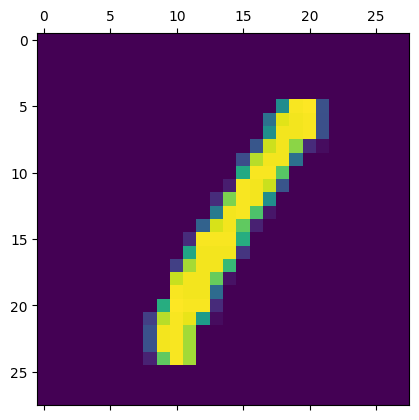

In [33]:
plt.matshow(x_train[3])

In [34]:
## Build a model

In [35]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [36]:
## compile the model

In [37]:
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])

In [38]:
## train the model

In [39]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8236 - loss: 1.4342
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9110 - loss: 0.3399
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9403 - loss: 0.2233
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9501 - loss: 0.1838
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9587 - loss: 0.1530


In [40]:
## evaluate the model

In [41]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9612 - loss: 0.1445


[0.14453324675559998, 0.9611999988555908]

In [42]:
## make prediction

In [43]:
y_pred = model.predict(x_test)
y_lable = y_pred.argmax(axis=1)
y_lable

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [44]:
## visualize prediction and true image

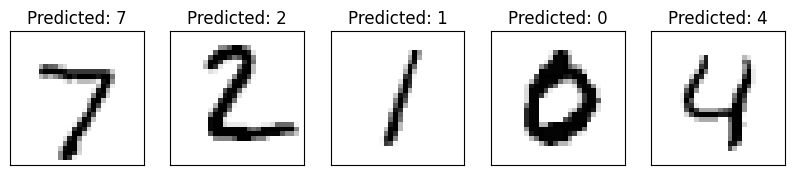

In [45]:
plt.figure(figsize=(10,10))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i], cmap=plt.cm.binary)
    plt.title(f"Predicted: {y_lable[i]}")

In [46]:
## build a confusion matrix

Text(95.72222222222221, 0.5, 'True')

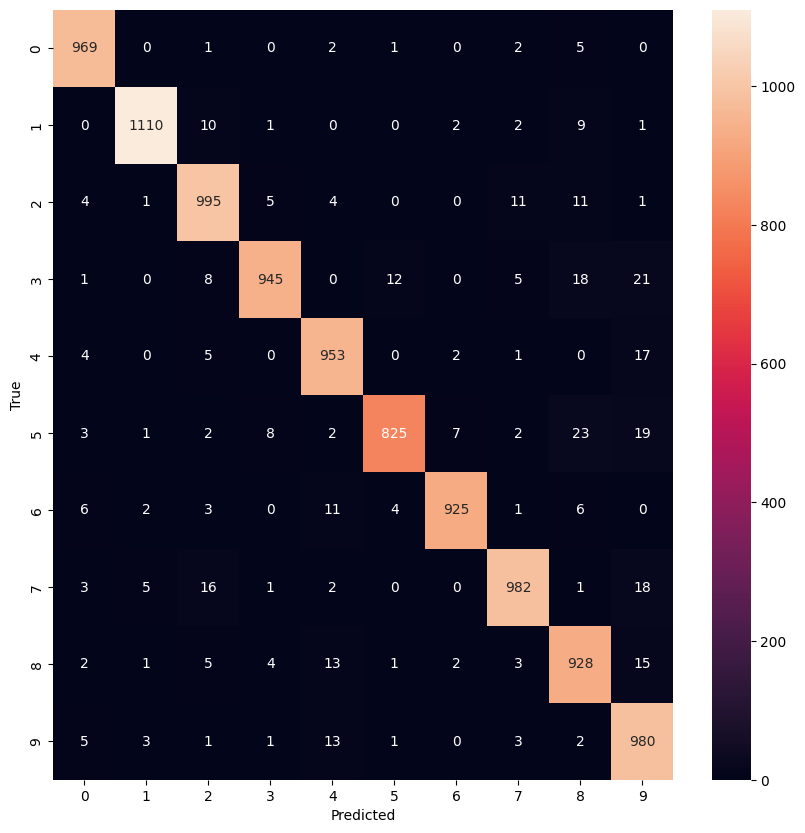

In [47]:
cm = tf.math.confusion_matrix(y_test, y_lable)
cm
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('True')